1. Install Required Libraries

In [1]:
!pip install scikit-learn pandas matplotlib seaborn

2. Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

TASK 1 – Decision Tree Classifier

Step 3: Load Iris Dataset

In [3]:
iris = load_iris()

X = iris.data
y = iris.target

print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)

Features Shape: (150, 4)
Labels Shape: (150,)


Step:- 4 Split Data into Training and Testing Sets

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 120
Testing Samples: 30


Step:-5 Train Decision Tree Model

In [5]:
dt_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Model Training Complete!")

Model Training Complete!


Step:-6  Make Predictions

In [6]:
y_pred = dt_model.predict(X_test)

print("Actual Labels:")
print(y_test[:10])

print("Predicted Labels:")
print(y_pred[:10])

Actual Labels:
[0 2 1 1 0 1 0 0 2 1]
Predicted Labels:
[0 2 1 1 0 1 0 0 2 1]


Step 7: Predict a New Flower

In [7]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = dt_model.predict(new_flower)

print("Predicted Species:")
print(iris.target_names[prediction[0]])

Predicted Species:
setosa


Step 8: Evaluate the Model

In [8]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy * 100)
print()

print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

Accuracy: 96.66666666666667

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



Step 9: Confusion Matrix

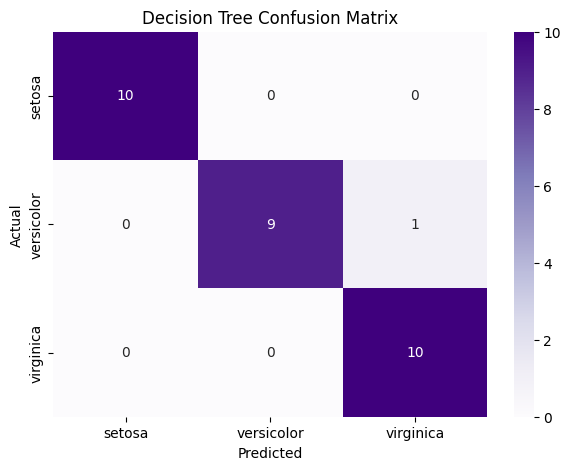

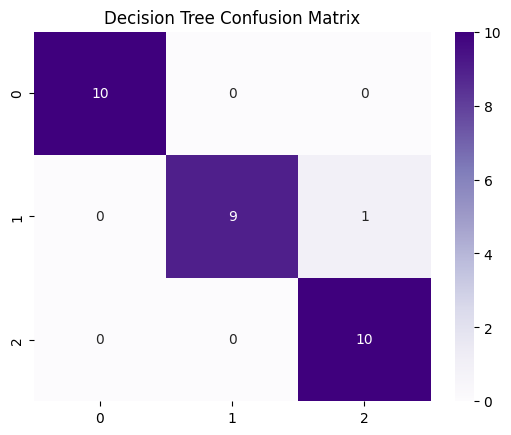

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')

plt.title("Decision Tree Confusion Matrix")

plt.savefig("confusion_matrix_dt.png", dpi=150)

plt.show()

Step 10: Visualize Decision Tree

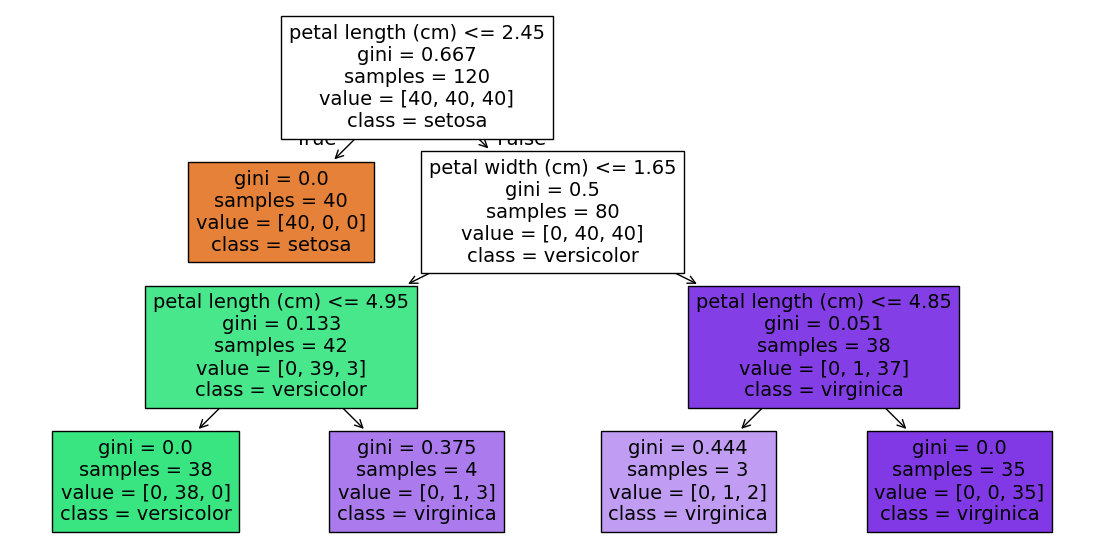

<Figure size 640x480 with 0 Axes>

In [21]:
plt.figure(figsize=(14,7))

plot_tree(
    dt_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()
plt.savefig("decision_tree_visual.png", dpi=150)

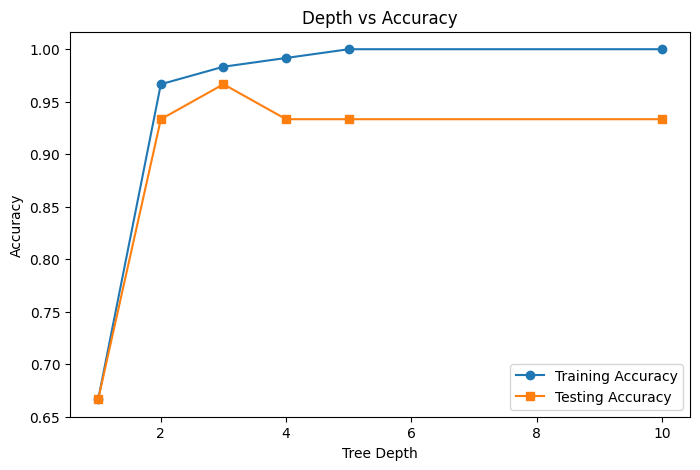

In [22]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

depths = [1,2,3,4,5,10]

train_acc = []
test_acc = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train,y_train)

    train_acc.append(
        model.score(X_train,y_train)
    )

    test_acc.append(
        model.score(X_test,y_test)
    )

plt.figure(figsize=(8,5))

plt.plot(depths, train_acc,
         marker='o',
         label='Training Accuracy')

plt.plot(depths, test_acc,
         marker='s',
         label='Testing Accuracy')

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Depth vs Accuracy")

plt.legend()

plt.savefig("depth_vs_accuracy.png", dpi=150)

plt.show()

TASK 2 – Random Forest Classifier

Step 11: Train Random Forest Model

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, y_pred_rf) * 100
)

Random Forest Accuracy: 93.33333333333333


Step 12: Cross Validation

In [12]:
from sklearn.model_selection import cross_val_score

rf_cv = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(rf_cv)

print("Mean Accuracy:")
print(rf_cv.mean())

Cross Validation Scores:
[0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Mean Accuracy:
0.9666666666666668


Step 13: Feature Importance

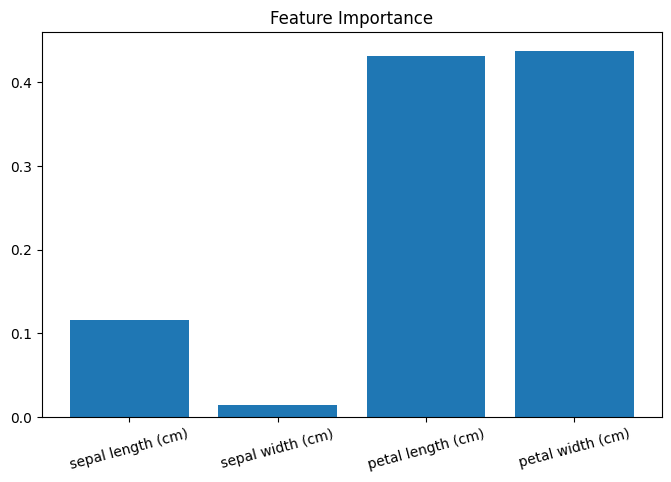

<Figure size 640x480 with 0 Axes>

In [19]:
importances = rf_model.feature_importances_

feature_names = iris.feature_names

plt.figure(figsize=(8,5))

plt.bar(feature_names, importances)

plt.title("Feature Importance")
plt.xticks(rotation=15)

plt.show()
plt.savefig("feature_importance.png", dpi=150)

Step 14: Compare Decision Tree vs Random Forest

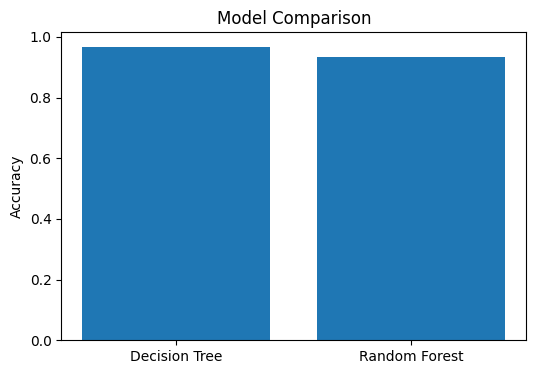

<Figure size 640x480 with 0 Axes>

In [18]:
models = ['Decision Tree', 'Random Forest']

scores = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_rf)
]

plt.figure(figsize=(6,4))

plt.bar(models, scores)

plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.show()
plt.savefig("model_comparison.png", dpi=150)

Step 15: Hyperparameter Tuning

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[50,100,200],
    'max_depth':[3,5,10,None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best Score:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 3, 'n_estimators': 50}
Best Score:
0.9583333333333334


final_confusion_matrix.png

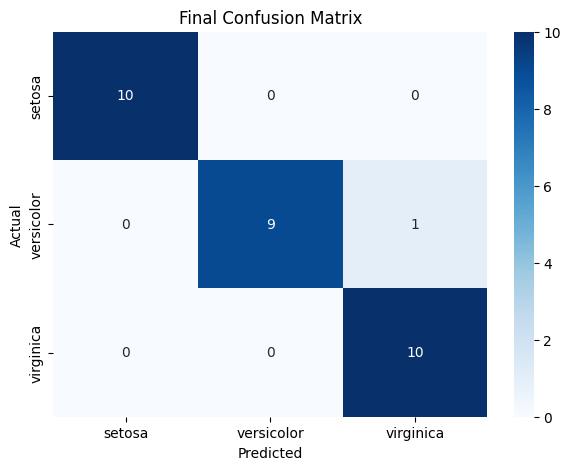

In [16]:
from sklearn.metrics import confusion_matrix

best_model = grid.best_estimator_

y_final_pred = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_final_pred
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Final Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "final_confusion_matrix.png",
    dpi=150
)

plt.show()